# A Basic Model

In this example application it is shown how a simple time series model can be developed to simulate groundwater levels. The recharge (calculated as precipitation minus evaporation) is used as the explanatory time series.

In [1]:
import pandas as pd

import pastas as ps

# ps.show_versions()

### 1. Importing the dependent time series data
In this codeblock a time series of groundwater levels is imported using the `read_csv` function of `pandas`. As `pastas` expects a `pandas` `Series` object, the data is squeezed. To check if you have the correct data type (a `pandas Series` object), you can use `type(oseries)` as shown below. 

The following characteristics are important when importing and preparing the observed time series:
- The observed time series are stored as a `pandas Series` object.
- The time step can be irregular.

The head is stored in the variable `gwdata` in the code cell below. The heads can be plotted using standard `pandas` commands or the built-in `ps.plots.series` method, which is shown below.

The data type of the oseries is: <class 'pandas.core.series.Series'>


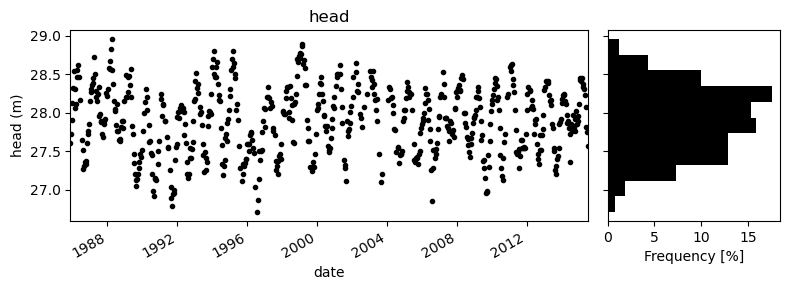

In [ ]:
# Import groundwater time seriesm and squeeze to Series object
gwdata = pd.read_csv(
    "../data/head_nb1.csv", parse_dates=["date"], index_col="date"
).squeeze()
print("The data type of the oseries is: %s" % type(gwdata))

# Plot the observed groundwater levels
ps.plots.series(head = gwdata, figsize=(8, 3), labels=["head (m)"]);

### 2. Import the independent time series
Two explanatory series are used: the precipitation and the potential evaporation. These need to be `pandas Series` objects, as for the observed heads.

Important characteristics of these time series are:
- All series are stored as `pandas Series` objects.
- The series may have irregular time intervals, but then it will be converted to regular time intervals when creating the time series model later on.
- It is preferred to use the same length units as for the observed heads.

The data type of the precip series is: <class 'pandas.core.series.Series'>
The data type of the evap series is: <class 'pandas.core.series.Series'>
The data type of the recharge series is: <class 'pandas.core.series.Series'>


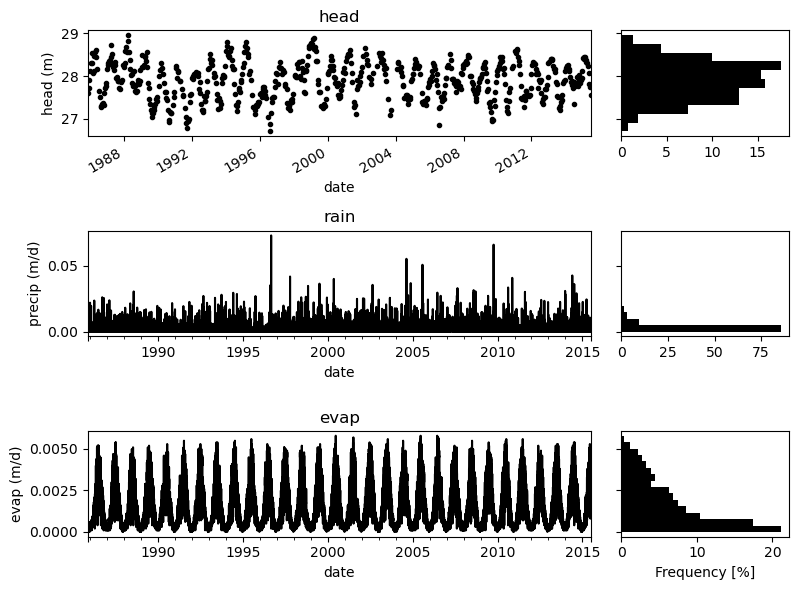

In [11]:
# Import observed precipitation series
precip = pd.read_csv(
    "../data/rain_nb1.csv", parse_dates=["date"], index_col="date"
).squeeze()
print("The data type of the precip series is: %s" % type(precip))

# Import observed evaporation series
evap = pd.read_csv(
    "../data/evap_nb1.csv", parse_dates=["date"], index_col="date"
).squeeze()
print("The data type of the evap series is: %s" % type(evap))

# Calculate the recharge to the groundwater
recharge = precip - evap
recharge.name = "recharge"  # set name if pandas series
print("The data type of the recharge series is: %s" % type(recharge))

# Plot the time series of the head, precipitation. and evaporation
ps.plots.series(
    head=gwdata,
    stresses=[precip, evap],
    figsize=(8, 6),
    labels=["head (m)", "precip (m/d)", "evap (m/d)"],
    # grid=True,
);

### 3. Create the time series model
In this code block the actual time series model is created. First, an instance of the `Model` class is created (named `ml` here). Second, the different components of the time series model are created and added to the model. The imported time series are automatically checked for missing values and other inconsistencies. The keyword argument fillnan can be used to determine how missing values are handled. If any nan-values are found this will be reported by `pastas`.

In [12]:
# Create a model object by passing it the observed series
ml = ps.Model(gwdata, name="GWL")

# Add the recharge data as explanatory variable
sm = ps.StressModel(recharge, ps.Gamma(), name="recharge", settings="evap")
ml.add_stressmodel(sm)

The Time Series 'recharge' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.


### 4. Solve the model
The next step is to compute the optimal model parameters. The default solver uses a non-linear least squares method for the optimization. The python package `scipy` is used (info on `scipy's` least_squares solver can be found [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html)). Some standard optimization statistics are reported along with the optimized parameter values and correlations.

In [13]:
ml.solve()

Fit report GWL                    Fit Statistics
nfev    11                     EVP         91.78
nobs    644                    R2           0.92
noise   False                  RMSE         0.12
tmin    1985-11-14 00:00:00    AICc     -2688.47
tmax    2015-06-28 00:00:00    BIC      -2670.66
freq    D                      Obj          4.89
warmup  3650 days 00:00:00     ___              
solver  LeastSquares           Interp.        No

Parameters (4 optimized)
               optimal     initial  vary
recharge_A  674.034359  215.674528  True
recharge_n    1.185049    1.000000  True
recharge_a  106.226376   10.000000  True
constant_d   27.588705   27.900078  True


### 5. Plot the results
The solution can be plotted after a solution has been obtained.

<Axes: xlabel='date', ylabel='Head'>

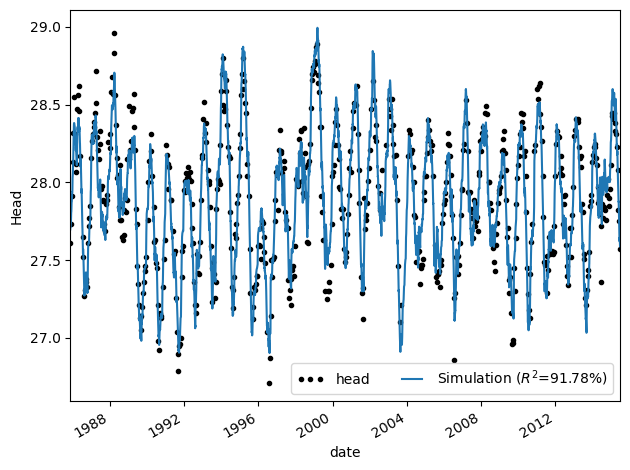

In [14]:
ml.plot()

### 6. Advanced plotting
There are many ways to further explore the time series model. `pastas` has some built-in functionalities that will provide the user with a quick overview of the model. The `plots` subpackage contains all the options. One of these is the method `plots.results` which provides a plot with more information.

[<Axes: xlabel='date', ylabel='Head'>,
 <Axes: xlabel='date'>,
 <Axes: title={'right': "Stresses: ['recharge']"}, ylabel='Rise'>,
 <Axes: title={'center': 'Step response'}, xlabel='Time [days]'>,
 <Axes: title={'left': 'Model Parameters ($n_c$=4)'}>]

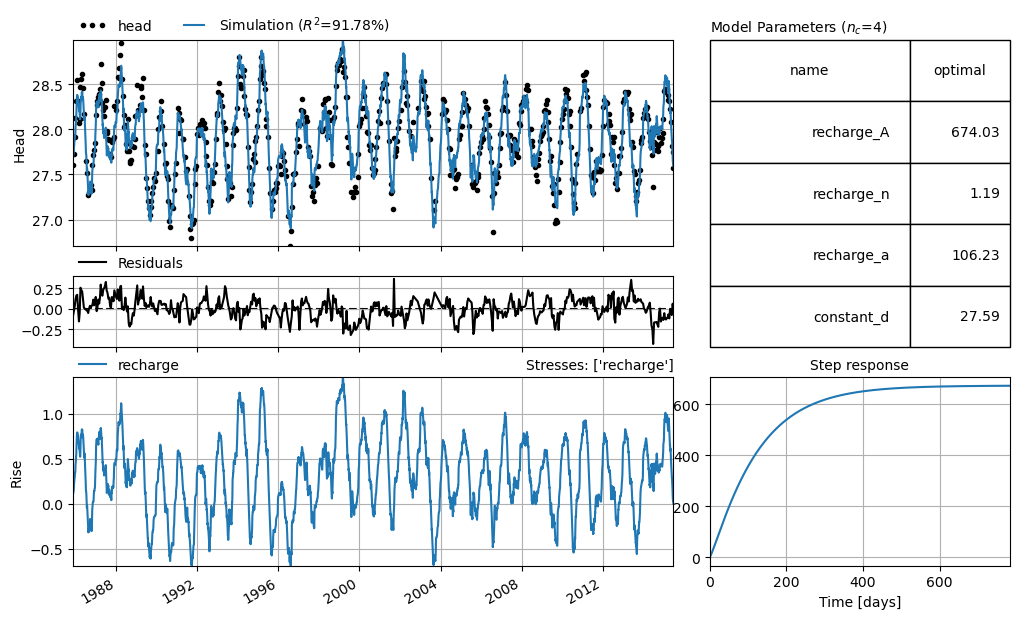

In [15]:
ml.plots.results(figsize=(10, 6))

### 7. Statistics
The `stats` subpackage includes a number of statistical functions that may applied to the model. One of them is the `summary` method, which gives a summary of the main statistics of the model.

In [16]:
ml.stats.summary()

,Value
Statistic,
rmse,0.123245
rmsn,NaN
sse,9.781998
mae,0.098034
nse,0.917782
evp,91.778169
rsq,0.917782
kge,0.940616
bic,-2670.657030


### 8. Improvement: estimate evaporation factor
In the previous model, the recharge was estimated as precipitation minus potential evaporation. A better model is to estimate the actual evaporation as a factor (called the evaporation factor here) times the potential evaporation. First, new model is created (called `ml2` here so that the original model `ml` does not get overwritten). Second, the `RechargeModel` object with a `Linear` recharge model is created, which combines the precipitation and evaporation series and adds a parameter for the evaporation factor `f`. The `RechargeModel` object is added to the model, the model is solved, and the results and statistics are plotted to the screen. Note that the new model gives a better fit (lower root mean squared error and higher explained variance), but that the Akiake information criterion indicates that the addition of the additional parameter does not improve the model significantly (the Akaike criterion for model `ml2` is higher than for model `ml`).

Fit report head                   Fit Statistics
nfev    13                     EVP         93.28
nobs    644                    R2           0.93
noise   False                  RMSE         0.11
tmin    1985-11-14 00:00:00    AICc     -2816.26
tmax    2015-06-28 00:00:00    BIC      -2794.01
freq    D                      Obj          4.00
warmup  3650 days 00:00:00     ___              
solver  LeastSquares           Interp.        No

Parameters (5 optimized)
               optimal     initial  vary
rainevap_A  618.950845  215.674528  True
rainevap_n    1.049266    1.000000  True
rainevap_a  146.190511   10.000000  True
rainevap_f   -1.408103   -1.000000  True
constant_d   28.019644   27.900078  True


,Value
Statistic,
rmse,0.111429
rmsn,NaN
sse,7.996130
mae,0.086444
nse,0.932792
evp,93.279202
rsq,0.932792
kge,0.951650
bic,-2794.010733


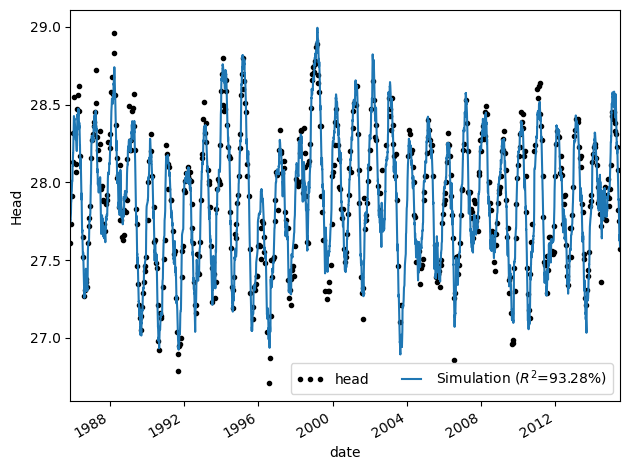

In [17]:
# Create a model object by passing it the observed series
ml2 = ps.Model(gwdata)

# Add the recharge data as explanatory variable
ts1 = ps.RechargeModel(
    precip,
    evap,
    ps.Gamma(),
    name="rainevap",
    recharge=ps.rch.Linear(),
    settings=("prec", "evap"),
)
ml2.add_stressmodel(ts1)

# Solve the model
ml2.solve()

# Plot the results
ml2.plot()

# Statistics
ml2.stats.summary()

### Origin of the series
* The rainfall data is taken from rainfall station Heibloem in The Netherlands.
* The evaporation data is taken from weather station Maastricht in The Netherlands.
* The head data is well B58C0698, which was obtained from Dino loket